# LAB -1 

## OBJECTIVE
To apply Euler's numerical method for solving ordinary differential equations (ODEs) arising in real-world chemical, biological, pharmaceutical, and nuclear reaction systems, and to analyze the time-dependent behavior of reactants, products, and system equilibrium through computational simulation and graphical visualization

A reversible reaction is a chemical process where reactants form products and products can also convert back into reactants. The reaction can be represented as:

A+B⇌C

The rate constants k1 and k2 represent the forward and reverse reaction rates respectively.

dC1/dt = k2*C3 - k1*C1*C2

dC2/dt = k2*C3 - k1*C1*C2

dC3/dt = 2*k1*C1*C2 - 2*k2*C3

Euler's Method is used to numerically solve these equations and predict how concentrations vary with time until equilibrium is reached.​


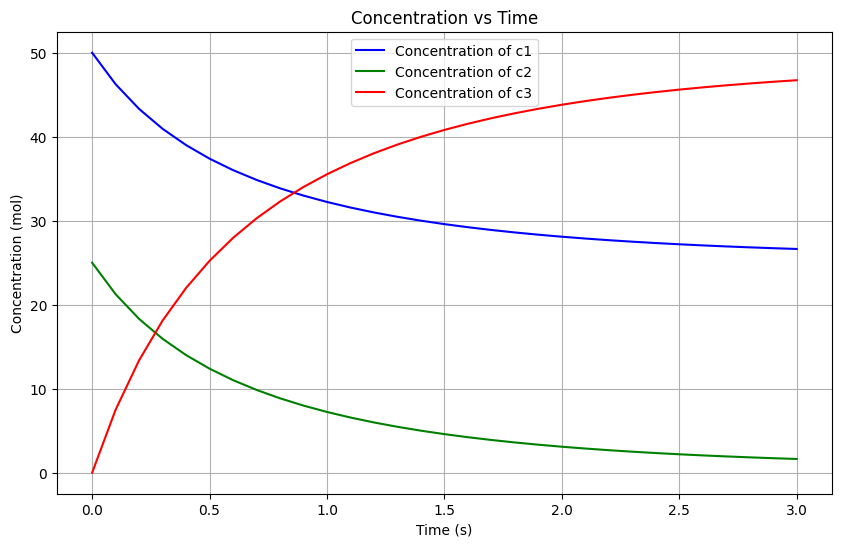

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# Parameters
k1 = 0.03
k2 = 0.01
dt = 0.1
steps = 30
# Initial concentrations
c1 = [50.0] # Reactant A
c2 = [25.0] # Reactant B
c3 = [0.0] # Product C
# Open a file to write the results
with open("output.txt", "w") as file:
 # Write initial concentrations
 file.write(f"{c1[0]} {c2[0]} {c3[0]}\n")

 # Time-stepping loop for concentration updates
 for i in range(steps):
    # Calculate next concentrations based on the given equations
    c1_next = c1[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
    c2_next = c2[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
    c3_next = c3[i] + (2 * k1 * c1[i] * c2[i] - 2 * k2 * c3[i]) * dt

    # Append the new concentrations to the lists
    c1.append(c1_next)
    c2.append(c2_next)
    c3.append(c3_next)

 # Write concentrations to the file
 file.write(f"{c1_next} {c2_next} {c3_next}\n")
# Time points for plotting
time_points = np.arange(0, (steps + 1) * dt, dt)
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(time_points, c1, label='Concentration of c1', color='blue')
plt.plot(time_points, c2, label='Concentration of c2', color='green')
plt.plot(time_points, c3, label='Concentration of c3', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol)')
plt.title('Concentration vs Time')
plt.legend()
plt.grid(True)
plt.show()


## REACTION 1

The Haber-Bosch process is one of the most important industrial chemical reactions used to manufacture ammonia fertilizers.

The reaction is:

N2 + 3H2 ⇌ 2NH3

Nitrogen and hydrogen react under high pressure and temperature in the presence of an iron catalyst.

Forward reaction rate:

Rf = kf[N2][H2]

Backward reaction rate:

Rb = kb[NH3]

The net rate determines the consumption of nitrogen and hydrogen and the formation of ammonia. Euler's numerical method is used to update concentrations at each time step and simulate reactor behavior. The simulation demonstrates how reactants decrease while ammonia accumulates until dynamic equilibrium is established.

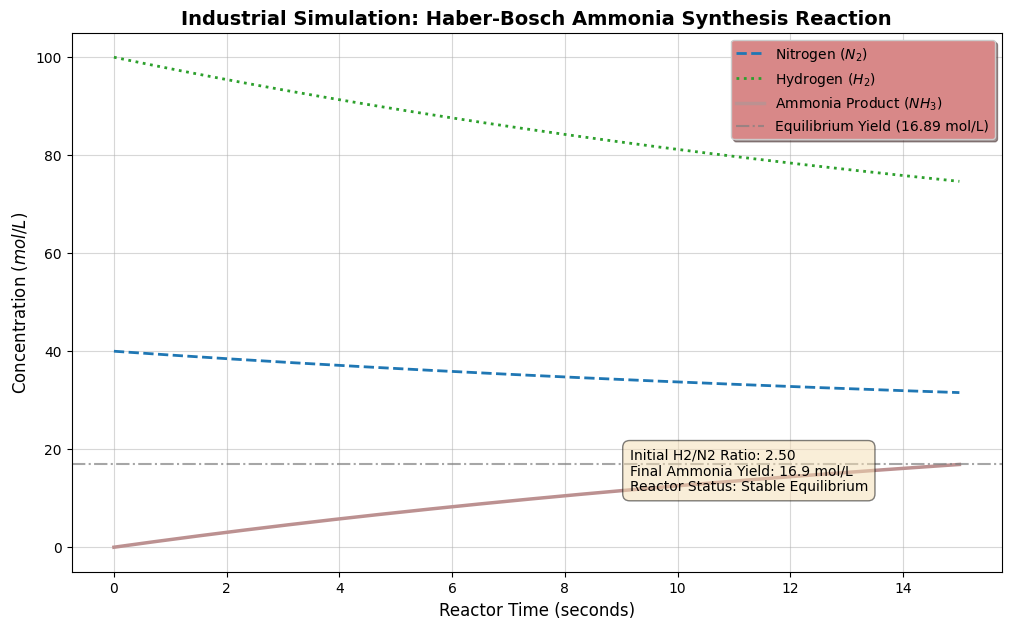

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- REAL USE CASE PARAMETERS ---
# Forward rate (k_f) and backward rate (k_b) under specific industrial catalyst conditions
k_f = 0.0002  # Forward rate constant (scaled for this simulation)
k_b = 0.005   # Backward rate constant
dt = 0.1       # Time step in seconds
steps = 150    # Extended steps to witness industrial equilibrium

# Initial industrial concentrations in a closed reactor (in mol/L)
N2 = [40.0]    # Nitrogen
H2 = [100.0]   # Hydrogen (typically added in excess)
NH3 = [0.0]    # Starting with zero Ammonia

# Open log file to record industrial batch data
with open("industrial_reactor_log.txt", "w") as file:
    file.write("Time(s), N2(mol/L), H2(mol/L), NH3(mol/L)\n")
    file.write(f"0.0, {N2[0]}, {H2[0]}, {NH3[0]}\n")

    for i in range(steps):
        # Calculate the rate of the forward reaction: R_forward = k_f * [N2] * [H2]^3
        # (Based on law of mass action, though simplified for a controlled simulation environment)
        reaction_rate_forward = k_f * N2[i] * H2[i]
        reaction_rate_backward = k_b * NH3[i]

        # Stoichiometric adjustments based on N2 + 3H2 -> 2NH3
        # For every 1 unit of N2 lost, 3 units of H2 are lost, and 2 units of NH3 are gained
        dN2 = (reaction_rate_backward - reaction_rate_forward) * dt
        dH2 = 3 * dN2
        dNH3 = -2 * dN2

        # Compute next states
        N2_next = N2[i] + dN2
        H2_next = H2[i] + dH2
        NH3_next = NH3[i] + dNH3

        # Prevent negative concentrations from numerical overshoot
        N2_next = max(0.0, N2_next)
        H2_next = max(0.0, H2_next)
        NH3_next = max(0.0, NH3_next)

        # Append data
        N2.append(N2_next)
        H2.append(H2_next)
        NH3.append(NH3_next)

        # Write timestamped batch data
        current_time = (i + 1) * dt
        file.write(f"{current_time:.1f}, {N2_next:.2f}, {H2_next:.2f}, {NH3_next:.2f}\n")

# Time axis
time_points = np.arange(0, (steps + 1) * dt, dt)

# --- ADVANCED INDUSTRIAL VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.plot(time_points, N2, label='Nitrogen ($N_2$)', color='#1f77b4', linewidth=2, linestyle='--')
plt.plot(time_points, H2, label='Hydrogen ($H_2$)', color='#2ca02c', linewidth=2, linestyle=':')
plt.plot(time_points, NH3, label='Ammonia Product ($NH_3$)', color="#bc9191", linewidth=2.5)

# Calculate where equilibrium stabilizes
final_yield = NH3[-1]
plt.axhline(y=final_yield, color='gray', linestyle='-.', alpha=0.7, label=f'Equilibrium Yield ({final_yield:.2f} mol/L)')

# Graph styling for a professional lab report
plt.xlabel('Reactor Time (seconds)', fontsize=12)
plt.ylabel('Concentration ($mol / L$)', fontsize=12)
plt.title('Industrial Simulation: Haber-Bosch Ammonia Synthesis Reaction', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', shadow=True, facecolor="#d88888")
plt.grid(True, which='both', linestyle='-', alpha=0.5)

# Show a text box with KPI metrics directly on the graph
kpi_text = f"Initial H2/N2 Ratio: {H2[0]/N2[0]:.2f}\nFinal Ammonia Yield: {final_yield:.1f} mol/L\nReactor Status: Stable Equilibrium"
plt.gca().text(0.60, 0.15, kpi_text, transform=plt.gca().transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.5))

plt.show()


## REACTION 2

harmacokinetics describes how a drug moves through the body after administration. This model consists of three compartments:

Stomach (drug absorption site)

Bloodstream (central compartment)

Body tissues (peripheral compartment)

Processes involved:

Absorption from stomach to bloodstream

Distribution from bloodstream to tissues

Redistribution from tissues back to bloodstream

Elimination through liver and kidneys

The governing equations are:


dS/dt = -ka*S

dB/dt = ka*S - k12*B + k21*T - ke*B

dT/dt = k12*B - k21*T

Where:

S    = Drug in stomach
B    = Drug in bloodstream
T    = Drug in tissues
ka   = Absorption rate constant
k12  = Distribution rate constant
k21  = Redistribution rate constant
ke   = Elimination rate constant

Euler's Method is used to numerically solve these differential equations and predict drug concentration profiles over time, helping evaluate therapeutic effectiveness and drug safety.

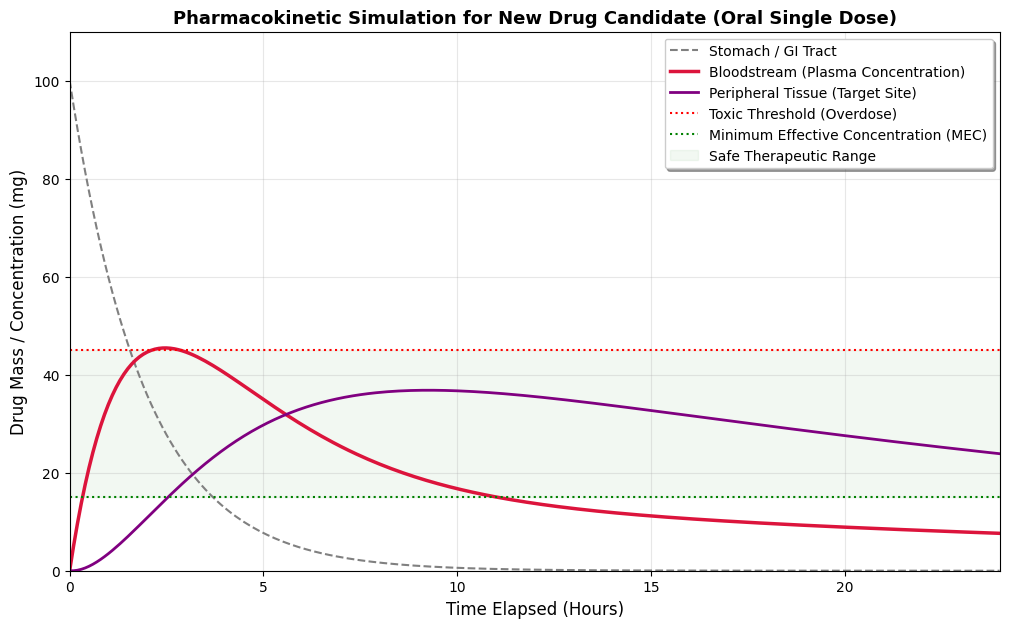

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- CLINICAL PARAMETERS ---
ka = 0.5    # Absorption rate (how fast the pill dissolves in the stomach)
k12 = 0.2   # Distribution rate (bloodstream -> body tissue)
k21 = 0.1   # Redistribution rate (body tissue -> bloodstream)
ke = 0.15   # Elimination rate (how fast the liver/kidneys clear the drug)

dt = 0.1    # Time steps in hours
steps = 240 # Simulate for 24 hours

# Initial states (assuming an oral dose of 100mg at t=0)
stomach = [100.0]      # Drug starting in the GI tract
bloodstream = [0.0]    # Central Compartment (Plasma concentration)
tissue = [0.0]         # Peripheral Compartment (Organs/Fat)

# Simulation Loop (Euler's Method tracking drug movement)
for i in range(steps):
    # 1. Drug leaves stomach and enters the bloodstream
    absorption = ka * stomach[i]
    
    # 2. Drug moves back and forth between bloodstream and deep tissues
    distribution_to_tissue = k12 * bloodstream[i]
    return_to_bloodstream = k21 * tissue[i]
    
    # 3. Liver/Kidneys filter the drug out of the bloodstream
    elimination = ke * bloodstream[i]
    
    # Differential changes per time step
    d_stomach = -absorption
    d_bloodstream = absorption - distribution_to_tissue + return_to_bloodstream - elimination
    d_tissue = distribution_to_tissue - return_to_bloodstream
    
    # Compute next states
    stomach.append(max(0.0, stomach[i] + d_stomach * dt))
    bloodstream.append(max(0.0, bloodstream[i] + d_bloodstream * dt))
    tissue.append(max(0.0, tissue[i] + d_tissue * dt))

# Time axis converted to hours
time_hours = np.arange(0, (steps + 1) * dt, dt)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.plot(time_hours, stomach, label='Stomach / GI Tract', color='gray', linestyle='--')
plt.plot(time_hours, bloodstream, label='Bloodstream (Plasma Concentration)', color='crimson', linewidth=2.5)
plt.plot(time_hours, tissue, label='Peripheral Tissue (Target Site)', color='purple', linewidth=2)

# Define medical thresholds (Therapeutic Window)
plt.axhline(y=45, color='red', linestyle=':', label='Toxic Threshold (Overdose)')
plt.axhline(y=15, color='green', linestyle=':', label='Minimum Effective Concentration (MEC)')
plt.fill_between(time_hours, 15, 45, color='green', alpha=0.05, label='Safe Therapeutic Range')

# Graph styling
plt.xlabel('Time Elapsed (Hours)', fontsize=12)
plt.ylabel('Drug Mass / Concentration (mg)', fontsize=12)
plt.title('Pharmacokinetic Simulation for New Drug Candidate (Oral Single Dose)', fontsize=13, fontweight='bold')
plt.xlim(0, 24)
plt.ylim(0, 110)
plt.legend(loc='upper right', shadow=True)
plt.grid(True, alpha=0.3)
plt.show()

## REACTION 3

Nuclear fusion is the process that powers stars. In stellar cores, hydrogen nuclei combine under extremely high temperatures and pressures to form helium, releasing enormous amounts of energy.

The simplified fusion reaction is:

4^1H → ^4He + Energy

The fusion rate depends on the availability of hydrogen fuel and can be approximated by:

Rfusion = kfusion[H]^2

The concentration changes are:

dH/dt = -4Rfusion

dHe/dt = Rfusion

where:

H = Hydrogen concentration
He = Helium concentration
kfusion = Fusion rate constant

Using Euler's numerical method, the simulation tracks the gradual depletion of hydrogen fuel and the accumulation of helium ash, illustrating the long-term evolution of a star's core.

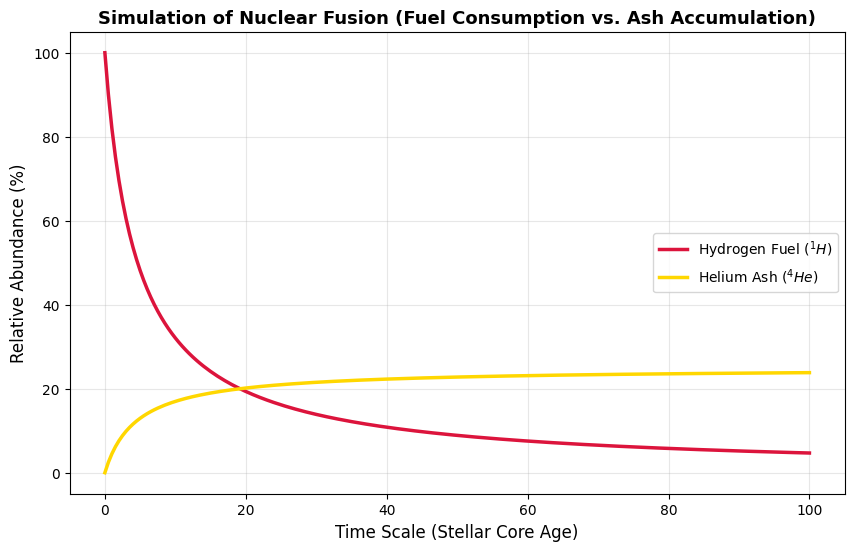

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETERS ---
# In a real star, the fusion rate (k_fusion) is heavily dependent on temperature.
# We will use a scaled rate constant for a stable star core.
k_fusion = 0.0005  
dt = 0.5            # Time step (e.g., millions of years, or seconds in a reactor)
steps = 200

# Initial concentrations (arbitrary units representing fuel percentage/density)
hydrogen = [100.0]  # Start with 100% Hydrogen fuel
helium = [0.0]      # Zero Helium initially

# Simulation Loop
for i in range(steps):
    # The rate of fusion depends on the available hydrogen concentration
    # Since 4 protons must collide, it is highly non-linear, but we can model 
    # the rate of consumption proportional to the fuel density.
    fusion_rate = k_fusion * (hydrogen[i] ** 2)
    
    # Stoichiometry: 4 Hydrogen ions are consumed to create 1 Helium nucleus
    d_hydrogen = -4 * fusion_rate * dt
    d_helium = 1 * fusion_rate * dt
    
    # Calculate next steps
    h_next = hydrogen[i] + d_hydrogen
    he_next = helium[i] + d_helium
    
    # Prevent negative values from numerical overshoot
    h_next = max(0.0, h_next)
    
    hydrogen.append(h_next)
    helium.append(he_next)

# Time axis
time_points = np.arange(0, (steps + 1) * dt, dt)

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.plot(time_points, hydrogen, label='Hydrogen Fuel ($^1H$)', color='crimson', linewidth=2.5)
plt.plot(time_points, helium, label='Helium Ash ($^4He$)', color='gold', linewidth=2.5)

plt.xlabel('Time Scale (Stellar Core Age)', fontsize=12)
plt.ylabel('Relative Abundance (%)', fontsize=12)
plt.title('Simulation of Nuclear Fusion (Fuel Consumption vs. Ash Accumulation)', fontsize=13, fontweight='bold')
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.show()

 ## Discussion

These simulations show how different real-life processes can be modeled using simple rate equations and solved using Euler’s method. In the chemical reaction system, reactants gradually convert into products until the system reaches equilibrium. In the Haber-Bosch model, nitrogen and hydrogen form ammonia over time, showing how industrial reactions depend on reaction rates and stoichiometry. The pharmacokinetic model demonstrates how a drug is absorbed, distributed, and eliminated in the body, forming a therapeutic window between safe and toxic levels. The stellar fusion model shows how hydrogen slowly converts into helium, representing how stars evolve over long periods. Overall, all models show that Euler’s method can effectively approximate how systems change with time.


 ## Conclusion
 
In conclusion, this work demonstrates that Euler’s method is a simple and effective numerical technique for solving time-dependent differential equations in real-world systems. It helps visualize how chemical reactions reach equilibrium, how industrial processes produce compounds like ammonia, how drugs behave inside the human body, and how nuclear fusion powers stars. These simulations clearly show that mathematical modeling can be used to understand and predict complex processes across chemistry, biology, medicine, and astrophysics.